# Regional composite eddies: depth, polarity and surface Rossby number
Compare **S1, S2, U1, U2, D1 and D2**, using the existing region assignment. There are 12 regional AE/CE baselines and 48 detailed groups: region × AE/CE × shallow/deep × low/high surface Rossby number. Empty groups remain visible in the inventory.

**Population and weighting.** All days with usable ESP profiles in these regions are eligible, irrespective of their old TiltDis/TiltDir, PV dominance, shelf class or stratification. Each eddy-day is translated to its fitted surface centre, and days receive equal weight. Region, |Ro|, and depth-extent classes are assigned per day; one track can enter multiple groups as it evolves. Baselines overlap their detailed groups, and group contrasts are not independent simply because the labels differ.

**Coordinates and tilt.** The primary tilt is surface-to-depth displacement in geographic east/north. Velocity arrays remain in native model-grid x/y; geographic sections rotate the sampling lines and velocities together. Exact fitted depth levels are used without vertical interpolation. Each day is reconstructed once and contributes to both its baseline and detailed group.

**Depth and Rossby classes.** Shallow means deepest valid fit ≤1,000 m; deep means >1,000 m. Low means |surface Ro| <0.5; high means ≥0.5. Unknown Ro days remain in baselines but enter neither low nor high. Depth extent is observed fitted extent, not proof of a physical eddy bottom.

**Uncertainty.** Whole-eddy bootstrap intervals retain the day-weighted estimator. Variance measures individual-day spread; confidence intervals measure sampling uncertainty in the mean. They do not include ESP fitting error. Sparse depths are flagged rather than using a minimum track count to discard otherwise valid days.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE=Path.cwd().resolve()
ANALYSIS=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS is None: raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subfolder')
WORK=ANALYSIS/'esp_population_composites'
DATASET_SRC=ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
ESP_ROOT=Path('/home/z5297792/ESP_zonodo')
for p in (ANALYSIS,WORK,DATASET_SRC,ESP_ROOT):
    if str(p) not in sys.path: sys.path.insert(0,str(p))
import functions as esp
import seacofs_tilt_tools as tilt
import planetary_composite_tools as pct
import composite_comparison_tools as ccomp
import regional_composite_tools as rct
pd.set_option('display.max_columns',60)


In [2]:
# Population/analysis controls: none of the diagnostics below adds a PV/shelf/N2 filter.
SPLIT_DEPTH_M=1000.
ROSSBY_SPLIT=.5
DOMINANCE_FACTOR=2.
SHELF_LON=154.75
ELLIPSE_FRAC=1.
USE_PV_CACHE=True
BOOTSTRAPS=500
SEED=731
MIN_PLOT_EDDIES=2
SPARSE_EDDIES=20  # visual warning only, not an input filter
WIDTH_KM,RES_KM=400.,10.
RUN_VELOCITY_COMPOSITES=True
RUN_COMPOSITE_FITS=True
SUMMARY_TARGET_DEPTH_M=850.
DEPTH_TOLERANCE_M=100.
MATCH_SHALLOW_TARGETS_M=[200.,500.,850.]
MATCH_DEEP_TARGETS_M=[200.,500.,850.,1500.]
# Load existing corrected N2 diagnostics if available; never compute a new N2 cache here.
LOAD_STRATIFICATION_DIAGNOSTICS=True
N2_CACHE=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v4_potential_density_core.parquet')
MIN_N2_CORE_VALID_FRACTION=.80


In [3]:
paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
surface,_=tilt.load_tilt_tables(paths,add_regions=True,grid=grid)
surface=tilt.add_pv_gradient_terms(surface,grid,core_mean=True,frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian',averaging='nonlinear',use_cache=USE_PV_CACHE)
# Refresh the established six labels even if PV was loaded from its saved table.
surface=tilt.add_region_labels(surface,grid)
vertical=tilt.load_vert(paths)
if LOAD_STRATIFICATION_DIAGNOSTICS and N2_CACHE.exists():
    sys.path.insert(0,str(ANALYSIS/'tilt_mechanisms'))
    import mechanism_tools as mech
    n2=mech.load_stratification_cache(N2_CACHE)
    fields=['Eddy','Day']+[c for c in n2 if c in [
        'N2_200m_core_s2','N2_500m_core_s2','N2_200m_core_valid_fraction','N2_500m_core_valid_fraction']]
    surface=surface.merge(n2[fields],on=['Eddy','Day'],how='left',validate='one_to_one')
    for z in [200,500]:
        coverage=f'N2_{z}m_core_valid_fraction'
        surface[f'N2_{z}m_s2']=surface[f'N2_{z}m_core_s2'].where(
            surface[coverage].ge(MIN_N2_CORE_VALID_FRACTION)) if coverage in surface else np.nan
    print('Loaded existing N2 cache; insufficient/unknown coverage stays unavailable.')
else:
    print('Stratification diagnostics unavailable or disabled; all other analysis continues.')
selection_audit,profile_audit,centred_profiles=rct.prepare_population(surface,vertical,
    split_depth=SPLIT_DEPTH_M,ro_split=ROSSBY_SPLIT,dominance_factor=DOMINANCE_FACTOR,shelf_lon=SHELF_LON)
centred_profiles=rct.bottom_audit(centred_profiles,grid)
display(selection_audit.groupby('selection_status').size().rename('eddy_days'))
display(profile_audit.groupby(['Region','Cyc','profile_status']).size().rename('eddy_days'))


Loaded existing N2 cache; insufficient/unknown coverage stays unavailable.


selection_status
outside named regions         2
selected                 127424
Name: eddy_days, dtype: int64

Region  Cyc  profile_status      
D1      AE   no valid surface fit     1470
             usable                  26371
        CE   no valid surface fit     1357
             usable                  18404
D2      AE   no valid surface fit      580
             usable                   8131
        CE   no valid surface fit      566
             usable                   5958
S1      AE   no valid surface fit      123
             usable                   2714
        CE   no valid surface fit      154
             usable                   4736
S2      AE   no valid surface fit      339
             usable                   5693
        CE   no valid surface fit      503
             usable                   8559
U1      AE   no valid surface fit      271
             usable                   8230
        CE   no valid surface fit      277
             usable                   8239
U2      AE   no valid surface fit      614
             usable                  10414
        CE   no vali

## Population inventory before reconstruction
Counts below include all 60 slots, including zero-count groups. Unknown Rossby numbers are reported in baselines. The same eddy may appear in several rows, so unique-eddy counts must not be summed across groups.

Local bottom checks use the original fitted centre at every depth and the nearest wet model-cell bathymetry. They flag below-bottom fitted levels and unavailable/out-of-domain checks; they **do not filter** the profiles or apply a bathymetric mask to the idealised ESP velocities. Bottom depth at the centre alone does not guarantee support across the entire eddy footprint.


,Region,cohort,Ro_class,Cyc,eddy_days,eddies,unknown_Ro_days,median_max_depth_m,median_abs_Ro,median_surface_Rc_km
0,S1,all,all,AE,2714,185,0,858.918478,0.355208,91.017321
1,S1,all,all,CE,4736,248,0,1492.971178,0.459375,62.272801
2,S2,all,all,AE,5693,247,0,1128.898331,0.423387,61.228297
3,S2,all,all,CE,8559,382,0,1971.212518,0.371155,53.366751
4,U1,all,all,AE,8230,325,0,1492.971178,0.309312,95.539153
5,U1,all,all,CE,8239,325,0,1971.212518,0.331556,83.316711
6,U2,all,all,AE,10414,347,0,858.918478,0.225367,70.694042
7,U2,all,all,CE,13094,417,0,1128.898331,0.250236,72.411364
8,D1,all,all,AE,26371,723,0,1971.212518,0.273381,77.879003
9,D1,all,all,CE,18404,654,0,2568.677466,0.207553,71.426956


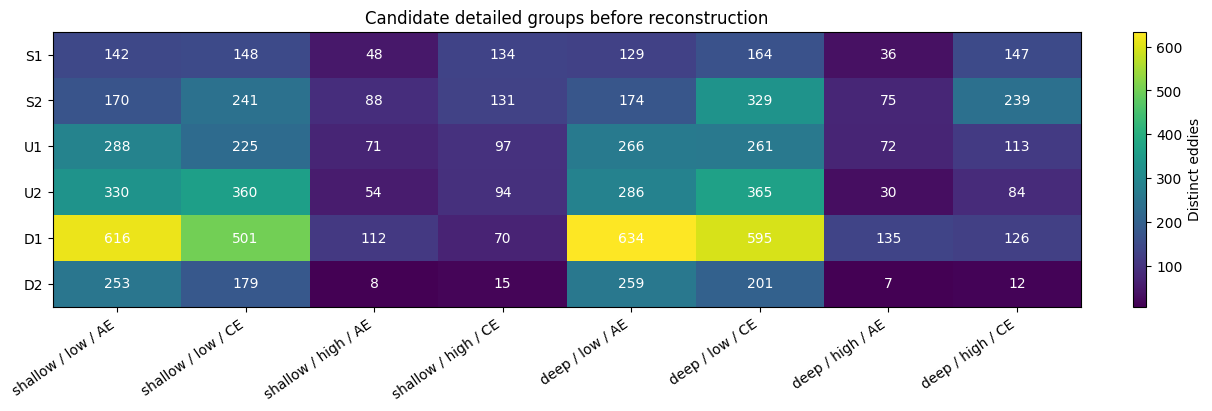

,fitted_levels,checked_levels,below_bottom_fraction
Depth,,,
0.000000,120543,120543,0.000000
5.879627,120543,120543,0.000000
10.725783,120543,120535,0.000000
16.383097,119527,119523,0.000000
22.925581,118927,118922,0.000000
30.444118,118488,118487,0.000000
39.052712,118103,118102,0.000000
48.897638,117700,117695,0.000000
60.170639,117260,117258,0.000000


In [4]:
population_inventory=rct.inventory(profile_audit)
with pd.option_context('display.max_rows',None): display(population_inventory)
count_matrix=population_inventory.loc[population_inventory.cohort.ne('all')].pivot(
    index='Region',columns=['cohort','Ro_class','Cyc'],values='eddies').reindex(rct.REGIONS)
fig,ax=plt.subplots(figsize=(12,4),constrained_layout=True)
im=ax.imshow(count_matrix.to_numpy(),aspect='auto',cmap='viridis')
ax.set(yticks=np.arange(len(count_matrix)),yticklabels=count_matrix.index,
       xticks=np.arange(len(count_matrix.columns)),xticklabels=[' / '.join(c) for c in count_matrix.columns])
plt.setp(ax.get_xticklabels(),rotation=35,ha='right')
for i in range(len(count_matrix)):
    for j in range(len(count_matrix.columns)):ax.text(j,i,int(count_matrix.iloc[i,j]),ha='center',va='center',color='white')
fig.colorbar(im,ax=ax,label='Distinct eddies');ax.set_title('Candidate detailed groups before reconstruction')
plt.show()
bottom_check=centred_profiles.groupby('Depth').agg(
    fitted_levels=('Day','size'),checked_levels=('below_local_bottom','count'),
    below_bottom_fraction=('below_local_bottom','mean'))
display(bottom_check)


## Construct each unique eddy-day once
All fields use paired finite u/v values and per-cell denominators. A contributing centre is retained only if the day supplied finite velocity somewhere at that level. With velocity reconstruction disabled, the mode is explicitly centre-only and no composite ESP fit or velocity plot is produced. Profile validity is unchanged from the breakdown notebook.

`regional_results[(region, cohort, Ro_class, Cyc)]` is the main container. Baselines use `('all','all')` for cohort and Ro class. For example: `regional_results[('U1','deep','high','CE')]`.


In [5]:
a=np.arange(-WIDTH_KM/2,WIDTH_KM/2+RES_KM/2,RES_KM)
X,Y=np.meshgrid(a,a)
regional_results,reconstruction_audit=rct.build_composites(profile_audit,centred_profiles,X,Y,esp,
    grid_angle=grid.angle,velocity=RUN_VELOCITY_COMPOSITES)
if not regional_results:raise ValueError('No contributing regional profiles')
rct.add_statistics(regional_results,n_boot=BOOTSTRAPS,seed=SEED)
centre_stats=rct.table(regional_results)
normalised_centre_stats=rct.table(regional_results,'normalised_stats')
contributor_inventory=pd.DataFrame([
    dict(zip(rct.KEYS,key),eddy_days=len(r['members'][['Eddy','Day']].drop_duplicates()),
         eddies=r['members'].Eddy.nunique(),mode=r['mode']) for key,r in regional_results.items()])
display(reconstruction_audit.groupby('reconstruction_status').size().rename('eddy_days'))
display(contributor_inventory)
print('Groups with contributors:',len(regional_results),'of 60')


Reconstructed 1000 unique eddy-days
Reconstructed 2000 unique eddy-days
Reconstructed 3000 unique eddy-days
Reconstructed 4000 unique eddy-days
Reconstructed 5000 unique eddy-days
Reconstructed 6000 unique eddy-days
Reconstructed 7000 unique eddy-days
Reconstructed 8000 unique eddy-days
Reconstructed 9000 unique eddy-days
Reconstructed 10000 unique eddy-days
Reconstructed 11000 unique eddy-days
Reconstructed 12000 unique eddy-days
Reconstructed 13000 unique eddy-days
Reconstructed 14000 unique eddy-days
Reconstructed 15000 unique eddy-days
Reconstructed 16000 unique eddy-days
Reconstructed 17000 unique eddy-days
Reconstructed 18000 unique eddy-days
Reconstructed 19000 unique eddy-days
Reconstructed 20000 unique eddy-days
Reconstructed 21000 unique eddy-days
Reconstructed 22000 unique eddy-days
Reconstructed 23000 unique eddy-days
Reconstructed 24000 unique eddy-days
Reconstructed 25000 unique eddy-days
Reconstructed 26000 unique eddy-days
Reconstructed 27000 unique eddy-days
Reconstruc

reconstruction_status
included    120543
Name: eddy_days, dtype: int64

,Region,cohort,Ro_class,Cyc,eddy_days,eddies,mode
0,D1,all,all,CE,18404,654,finite ESP contributors
1,D1,deep,low,CE,13614,595,finite ESP contributors
2,D1,all,all,AE,26371,723,finite ESP contributors
3,D1,deep,low,AE,16789,634,finite ESP contributors
4,S2,all,all,AE,5693,247,finite ESP contributors
5,S2,deep,low,AE,1689,174,finite ESP contributors
6,D1,shallow,low,CE,3965,501,finite ESP contributors
7,D1,deep,high,CE,600,126,finite ESP contributors
8,S2,all,all,CE,8559,382,finite ESP contributors
9,S2,deep,high,CE,2234,239,finite ESP contributors


Groups with contributors: 60 of 60


## Regional baselines and detailed tilt profiles
These figures compare AE/CE displacement magnitudes on common axes across all six regions. Open circles identify depths with fewer than `SPARSE_EDDIES` eddies; the underlying means remain available. The component plot below checks whether magnitude differences arise from different east/north directions.

The plotted metric is the length of the mean displacement vector. `mean_member_distance_km` and `coherence` remain in `centre_stats` to distinguish large individual tilts from consistent population alignment.


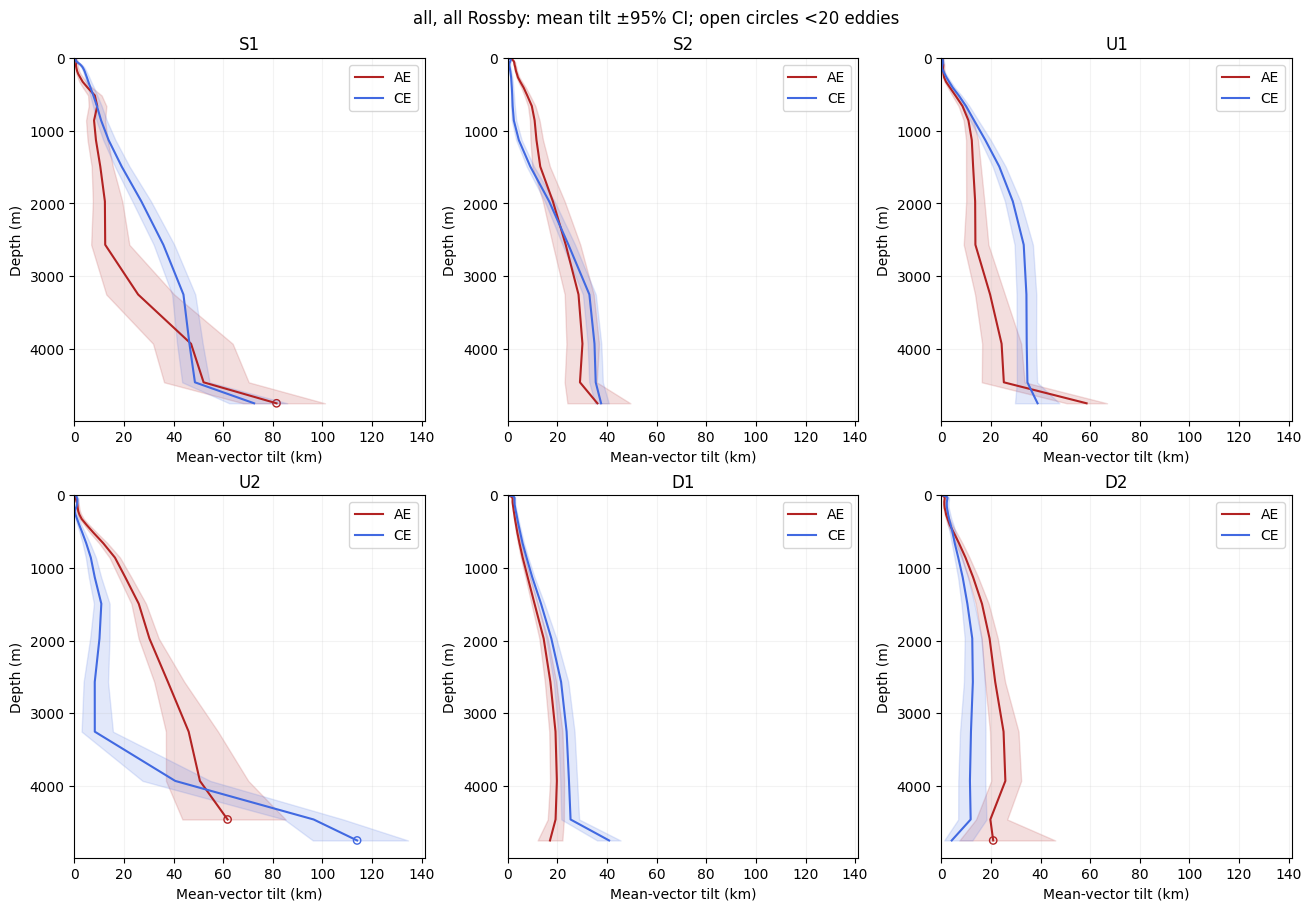

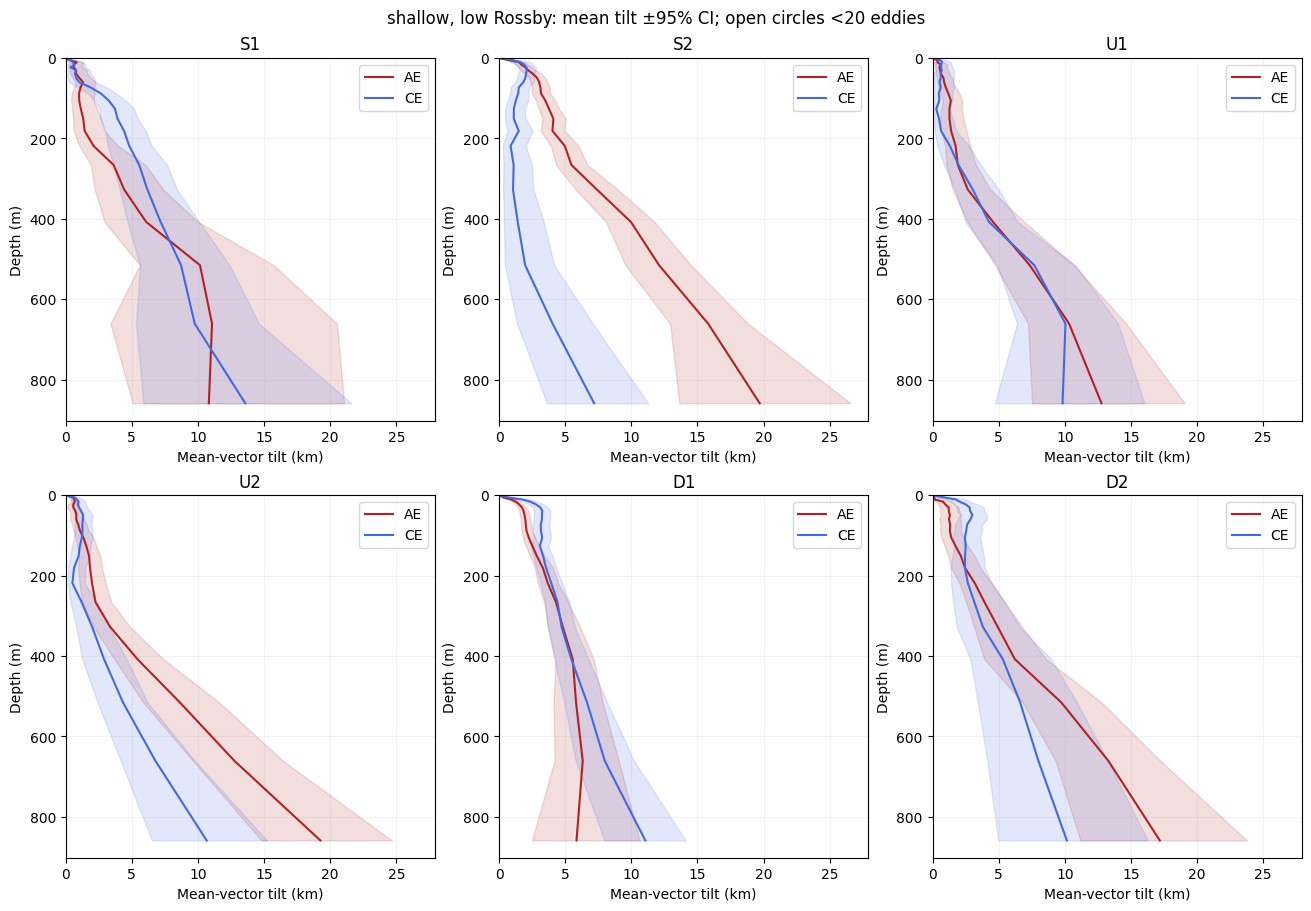

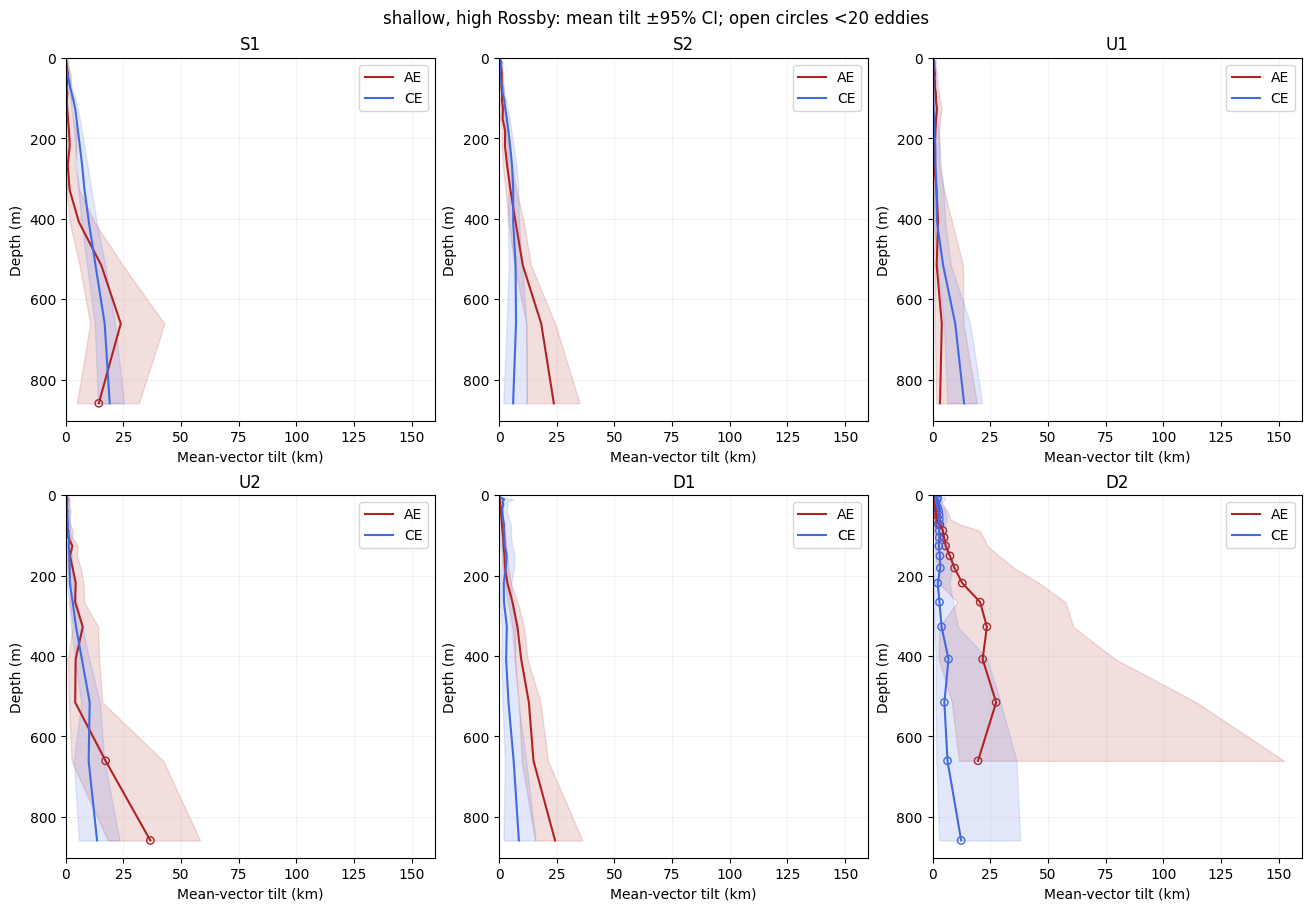

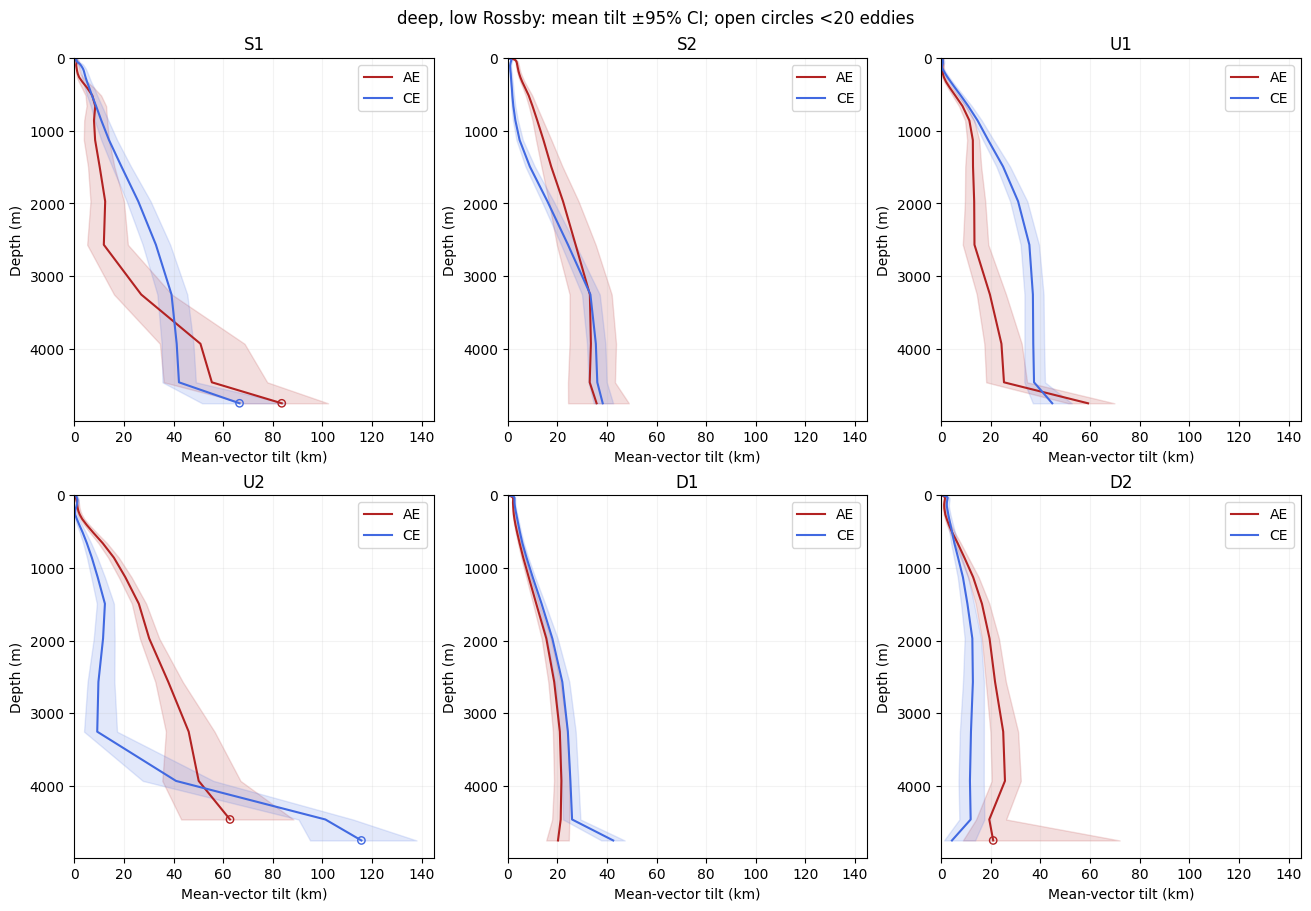

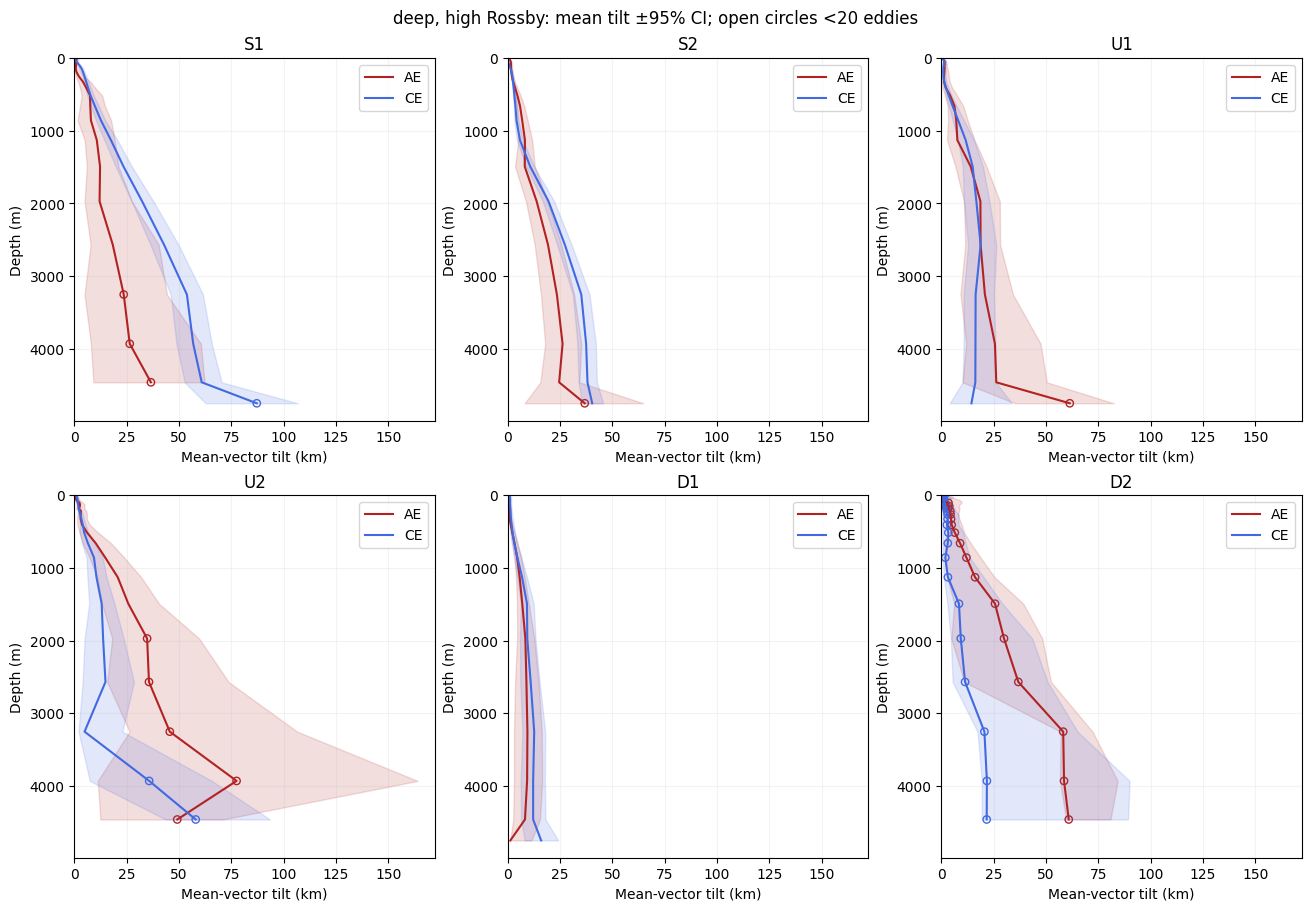

,Region,cohort,Ro_class,Cyc,Depth,n_eddy_days,n_eddies,coherence,bottom_checked_days,below_bottom_fraction
0,D1,all,all,CE,0.000000,18404,654,NaN,18404,0.0
1,D1,all,all,CE,5.879627,18404,654,0.119637,18404,0.0
2,D1,all,all,CE,10.725783,18404,654,0.183940,18404,0.0
3,D1,all,all,CE,16.383097,18206,653,0.219152,18206,0.0
4,D1,all,all,CE,22.925581,18100,653,0.239522,18100,0.0
...,...,...,...,...,...,...,...,...,...,...
1599,D2,shallow,high,AE,327.440851,15,6,0.729638,15,0.0
1600,D2,shallow,high,AE,407.922192,11,6,0.579297,11,0.0
1601,D2,shallow,high,AE,515.416489,9,5,0.499306,9,0.0
1602,D2,shallow,high,AE,660.806374,6,3,0.326862,6,0.0


In [6]:
rct.plot_regional_profiles(regional_results,min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
plt.show()
for cohort in ['shallow','deep']:
    for ro_class in ['low','high']:
        rct.plot_regional_profiles(regional_results,cohort,ro_class,
            min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
        plt.show()
# Support by exact depth, available for every baseline and detailed group.
display(centre_stats[list(rct.KEYS)+['Depth','n_eddy_days','n_eddies','coherence',
                                   'bottom_checked_days','below_bottom_fraction']])


In [1]:
# Change these controls to inspect one region's low/high-Ro differences in detail.
FOCUS_REGION='D1'
FOCUS_COHORT='deep'
FOCUS_RO_CLASS='high'
rct.plot_group_vectors(regional_results,FOCUS_REGION,FOCUS_COHORT,min_eddies=MIN_PLOT_EDDIES)
plt.show()
# fig,axs=plt.subplots(1,2,figsize=(10,4),constrained_layout=True)
# for ro,style in [('low','-'),('high','--')]:
#     for cyc in ['AE','CE']:
#         r=regional_results.get((FOCUS_REGION,FOCUS_COHORT,ro,cyc))
#         if r is None:continue
#         s=r['stats']
#         axs[0].plot(s.n_eddies,s.Depth,style,color=rct.COLORS[cyc],label=f'{cyc} {ro}')
#         axs[1].plot(s.below_bottom_fraction,s.Depth,style,color=rct.COLORS[cyc],label=f'{cyc} {ro}')
# for ax,label in zip(axs,['Distinct contributing eddies','Fraction of checked centres below local bottom']):
#     ax.set(xlabel=label,ylabel='Depth (m)');
#     if ax.lines:ax.legend(); ax.invert_yaxis()
# plt.show()


NameError: name 'rct' is not defined

## Tilt normalised by each day's surface Rc
Divide each member's east/north displacement by **its own fitted surface Rc before averaging**. Then take the norm of that averaged dimensionless vector and bootstrap over entire eddies. This is not the kilometre composite displacement divided by a mean radius.

Only the centre displacements are normalised. The velocity composites and their full ESP fits remain in physical kilometres and m/s. Each valid surface profile already requires a finite positive Rc. No new size-based selection is introduced.


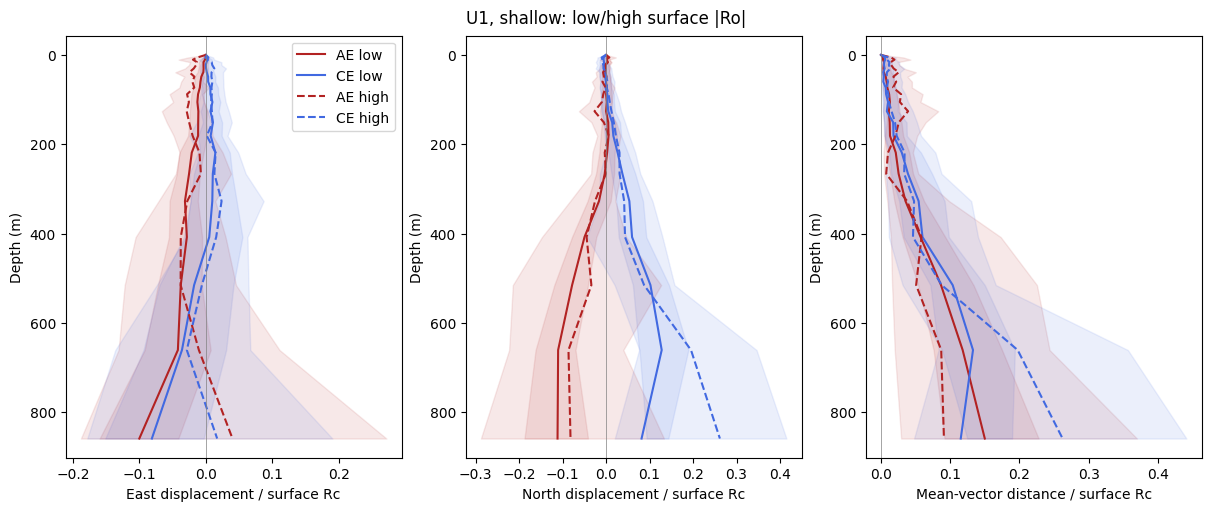

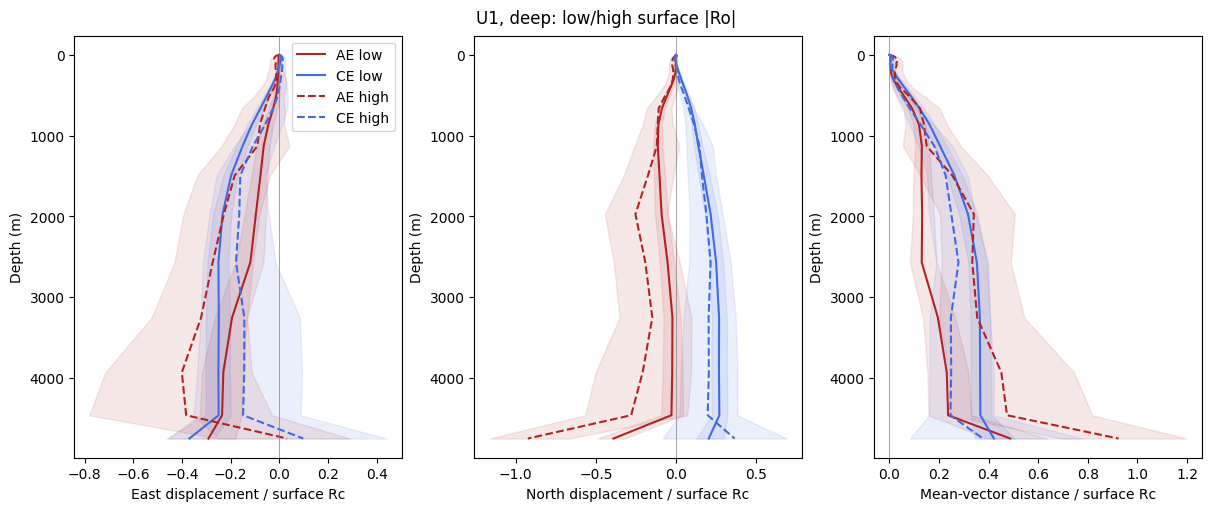

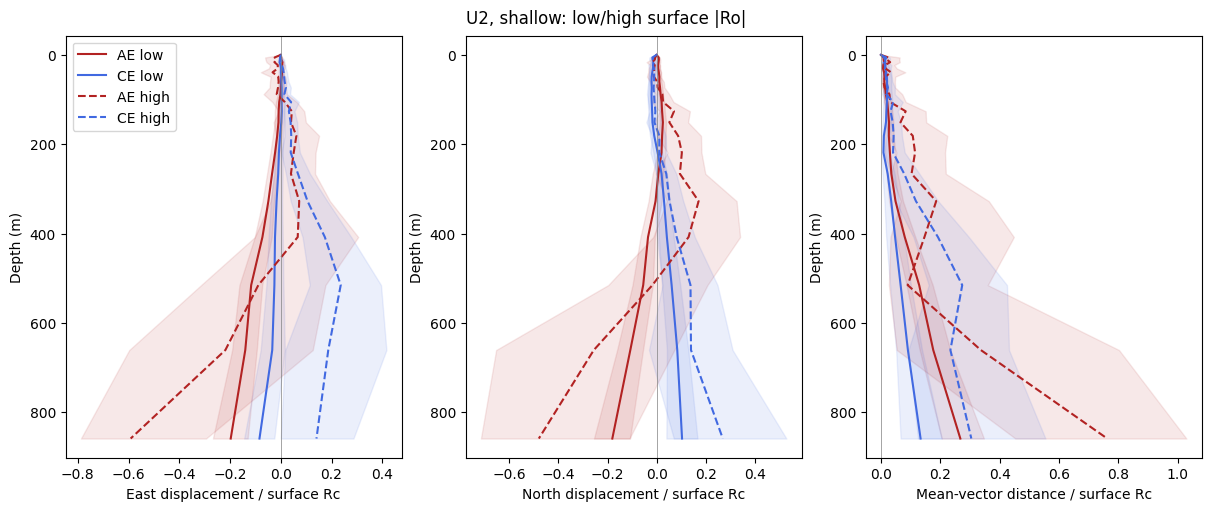

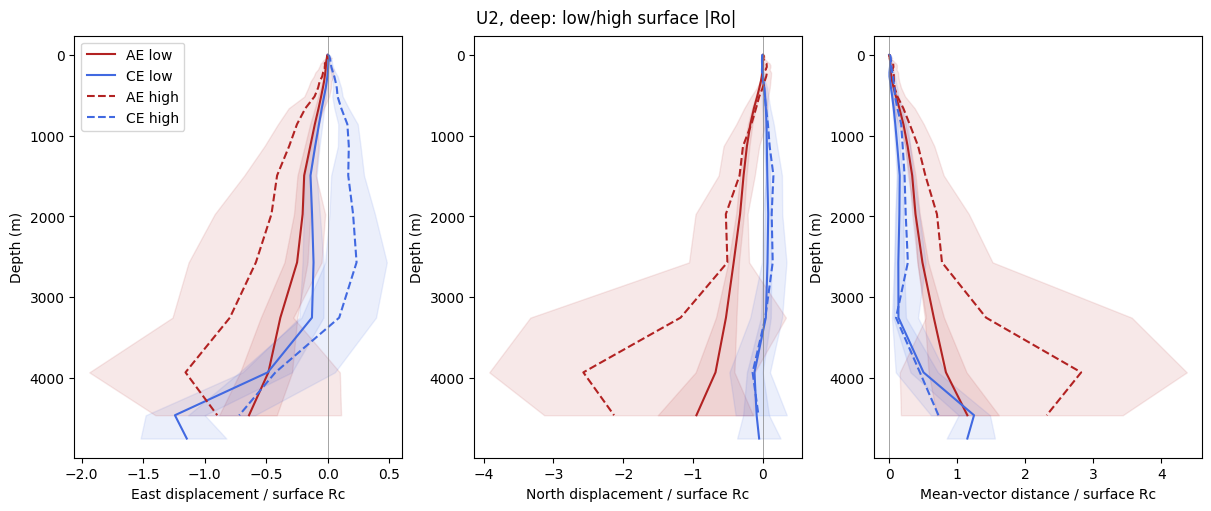

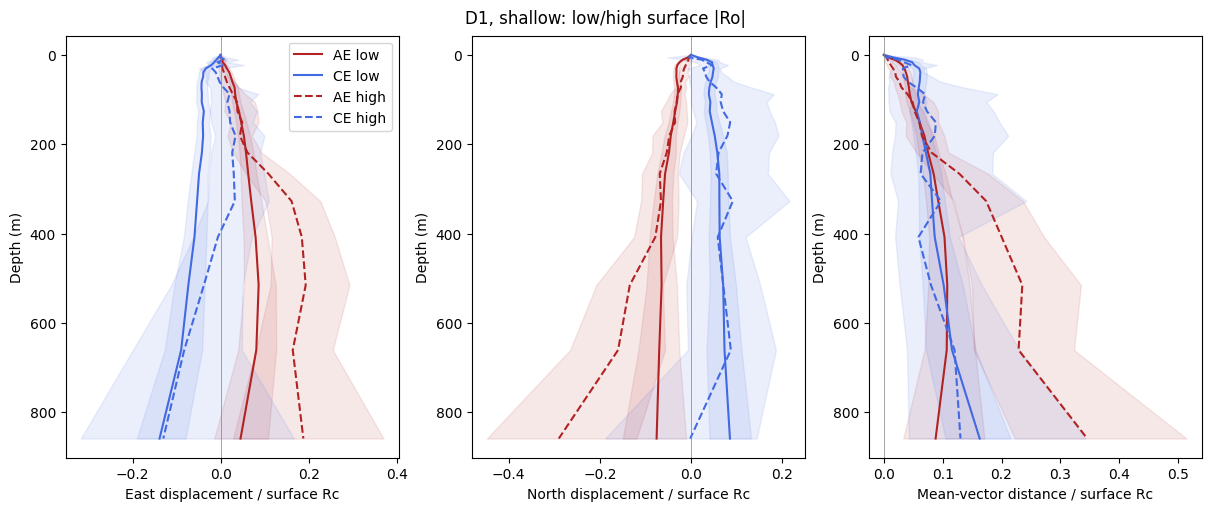

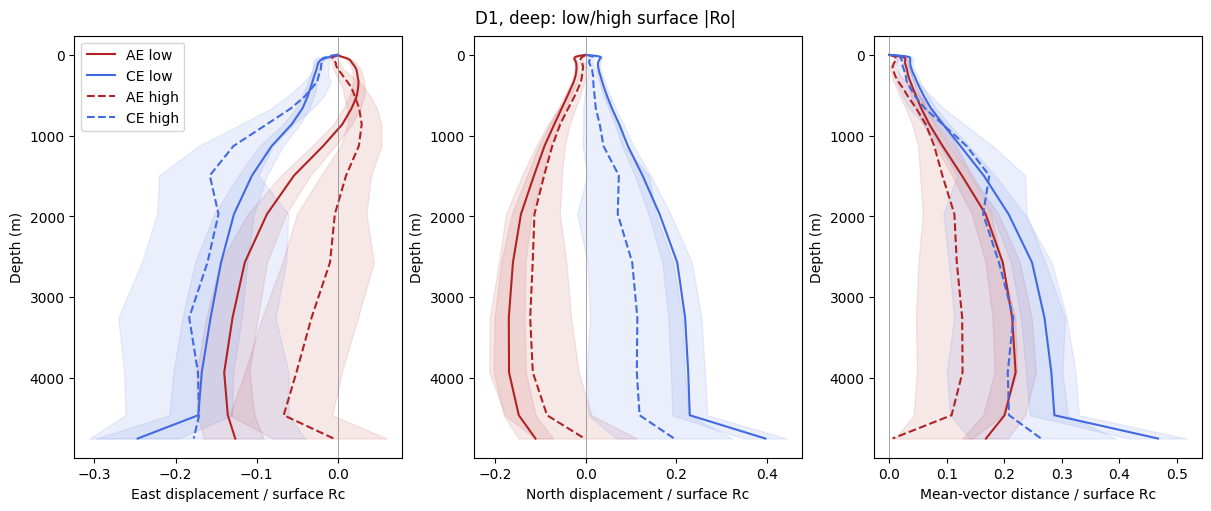

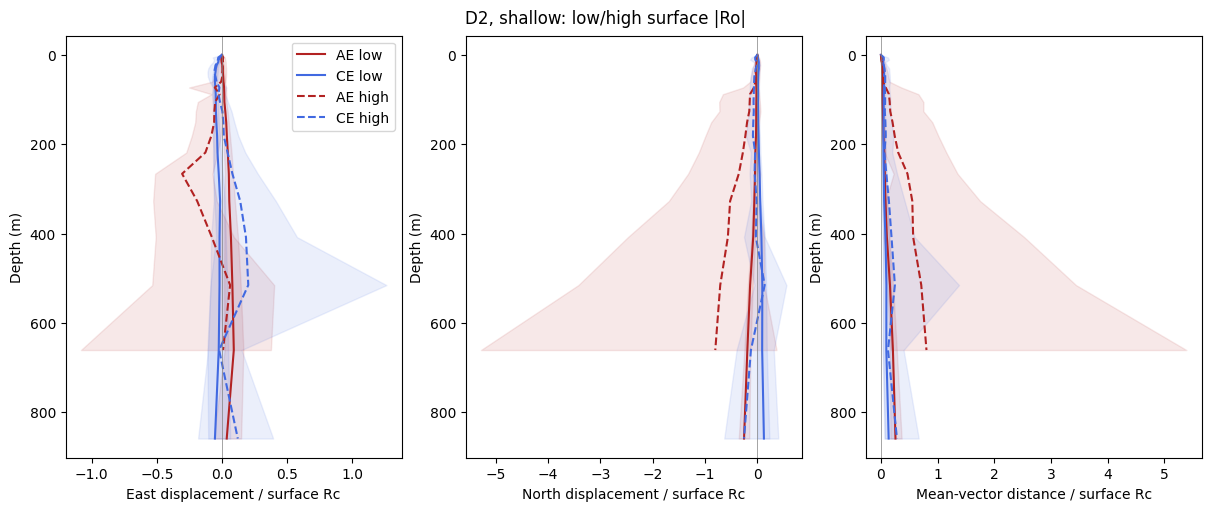

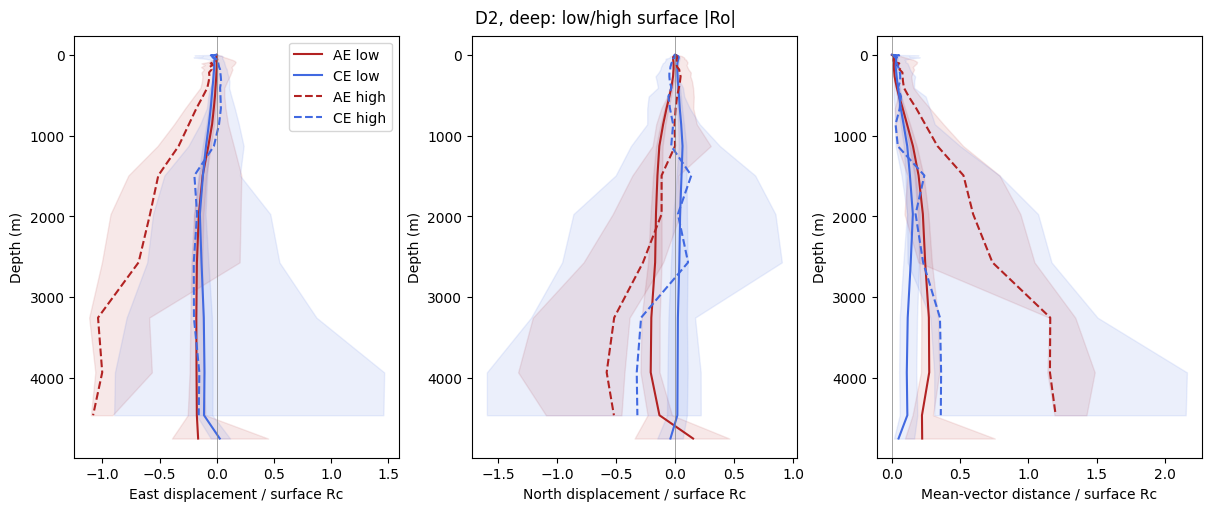

In [24]:
# for cohort in ['shallow','deep']:
#     for ro_class in ['low','high']:
#         rct.plot_regional_profiles(regional_results,cohort,ro_class,normalised=True,
#             min_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES)
#         plt.show()
for focus_region in ['U1','U2','D1','D2']:
    for focus_cohort in ['shallow', 'deep']:
        rct.plot_group_vectors(regional_results,focus_region,focus_cohort,normalised=True,min_eddies=MIN_PLOT_EDDIES)
        plt.show()


## Summary at one common physical depth
Resolve the requested depth once against the dataset's fitted depth grid. Every group is then assessed at that exact level. A group missing that level stays unavailable; it is never assigned its own nearest depth. Available but sparse rows are labelled. This avoids letting one sparse regional group choose a different reference depth for everyone.


In [9]:
targets=sorted(set([SUMMARY_TARGET_DEPTH_M]+MATCH_SHALLOW_TARGETS_M+MATCH_DEEP_TARGETS_M))
depth_map=rct.resolve_depths(centred_profiles.Depth.unique(),targets,DEPTH_TOLERANCE_M)
display(depth_map)
summary_depth=float(depth_map.set_index('target_m').loc[SUMMARY_TARGET_DEPTH_M,'Depth'])
tilt_summary=rct.summary_at_depth(regional_results,summary_depth,min_eddies=MIN_PLOT_EDDIES)
with pd.option_context('display.max_rows',None):display(tilt_summary)


,target_m,Depth,status
0,200.0,181.264793,ok
1,500.0,515.416489,ok
2,850.0,858.918478,ok
3,1500.0,1492.971178,ok


,Region,cohort,Ro_class,Cyc,Depth,status,distance_km,ci_low,ci_high,distance_Rc,n_eddies,n_eddy_days
0,D1,all,all,CE,858.918478,ok,7.544610,6.781225,8.211195,0.096179,621,15099
1,D1,deep,low,CE,858.918478,ok,7.530550,6.741820,8.232376,0.093458,595,13614
2,D1,all,all,AE,858.918478,ok,5.979249,5.215470,6.687296,0.069753,655,20292
3,D1,deep,low,AE,858.918478,ok,6.203751,5.393928,6.933843,0.069585,634,16789
4,S2,all,all,AE,858.918478,ok,10.795045,8.905994,12.785072,0.164774,202,3473
5,S2,deep,low,AE,858.918478,ok,11.859381,9.906410,14.135266,0.156173,174,1689
6,D1,shallow,low,CE,858.918478,ok,11.052651,7.967513,14.108112,0.162932,284,833
7,D1,deep,high,CE,858.918478,ok,4.579439,3.090100,6.437938,0.092801,126,600
8,S2,all,all,CE,858.918478,ok,2.414777,1.595761,3.399566,0.045005,370,7216
9,S2,deep,high,CE,858.918478,ok,4.139576,3.118326,5.124603,0.101604,239,2234


## Fixed-membership sensitivity
Within each detailed group, keep only days present at **every resolved target depth plus the surface**. Shallow and deep groups use separate target lists because shallow profiles cannot reach the deeper targets. Across regions/Rossby/polarity groups, the target list is identical for the same depth cohort.

The matched curves are evaluated only at those target levels, so membership is truly fixed along each plotted curve. The normalised estimator is recomputed on the same matched days. Empty matches and unresolved targets are reported without relaxing the rule. This sensitivity analysis is intentionally selective; the original available-day composites remain the main results.


,Region,cohort,Ro_class,Cyc,matched_days,matched_eddies,required_depths_m,status
0,D1,deep,low,CE,12116,576,"0, 181.265, 515.416, 858.918, 1492.97",ok
1,D1,deep,low,AE,15122,621,"0, 181.265, 515.416, 858.918, 1492.97",ok
2,S2,deep,low,AE,1410,159,"0, 181.265, 515.416, 858.918, 1492.97",ok
3,D1,shallow,low,CE,833,284,"0, 181.265, 515.416, 858.918",ok
4,D1,deep,high,CE,532,122,"0, 181.265, 515.416, 858.918, 1492.97",ok
5,S2,deep,high,CE,1874,225,"0, 181.265, 515.416, 858.918, 1492.97",ok
6,S2,shallow,high,CE,186,83,"0, 181.265, 515.416, 858.918",ok
7,S2,shallow,low,CE,390,139,"0, 181.265, 515.416, 858.918",ok
8,S2,deep,low,CE,3821,316,"0, 181.265, 515.416, 858.918, 1492.97",ok
9,D2,shallow,low,CE,323,94,"0, 181.265, 515.416, 858.918",ok


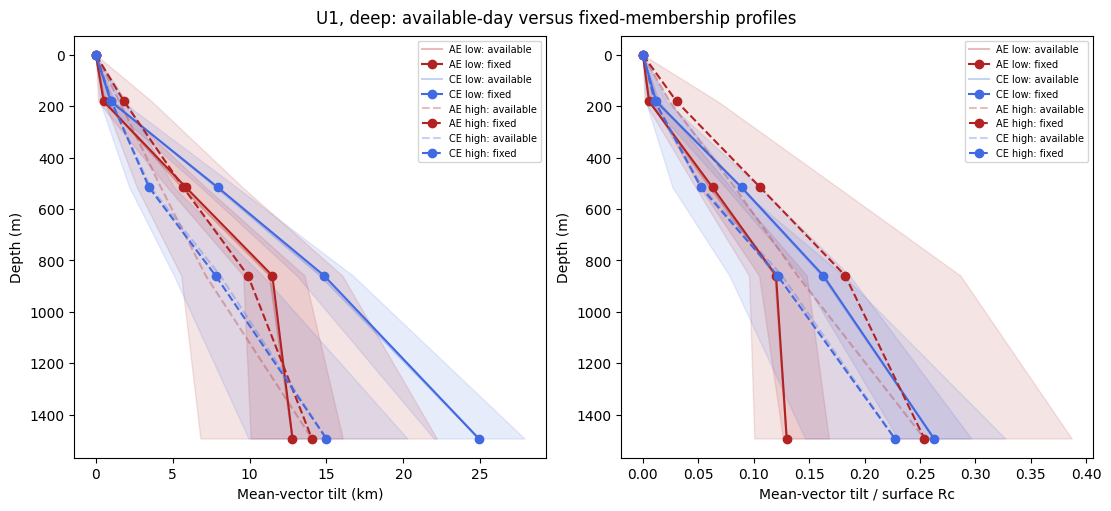

In [10]:
matched_results,matched_audit=rct.fixed_membership(regional_results,depth_map,
    MATCH_SHALLOW_TARGETS_M,MATCH_DEEP_TARGETS_M,n_boot=BOOTSTRAPS,seed=SEED)
display(matched_audit)
matched_centre_stats=rct.table(matched_results)
matched_normalised_stats=rct.table(matched_results,'normalised_stats')
fig,axs=plt.subplots(1,2,figsize=(11,5),constrained_layout=True)
for ro in ['low','high']:
    for cyc in ['AE','CE']:
        key=(FOCUS_REGION,FOCUS_COHORT,ro,cyc)
        if key not in matched_results:continue
        m=matched_results[key]
        for ax,field,col in [(axs[0],'stats','distance_km'),(axs[1],'normalised_stats','distance_Rc')]:
            s=m[field];orig=regional_results[key][field]
            orig=orig.loc[orig.Depth.isin(s.Depth)]
            style='-' if ro=='low' else '--'
            ax.plot(orig[col],orig.Depth,style,color=rct.COLORS[cyc],alpha=.3,label=f'{cyc} {ro}: available')
            ax.plot(s[col],s.Depth,style+'o',color=rct.COLORS[cyc],label=f'{cyc} {ro}: fixed')
            lo,hi=('distance_ci_low','distance_ci_high') if col=='distance_km' else ('distance_Rc_ci_low','distance_Rc_ci_high')
            ax.fill_betweenx(s.Depth,s[lo],s[hi],color=rct.COLORS[cyc],alpha=.12)
for ax,label in zip(axs,['Mean-vector tilt (km)','Mean-vector tilt / surface Rc']):
    ax.set(xlabel=label,ylabel='Depth (m)');ax.invert_yaxis()
    if ax.lines:ax.legend(fontsize=7)
fig.suptitle(f'{FOCUS_REGION}, {FOCUS_COHORT}: available-day versus fixed-membership profiles')
plt.show()


## Environmental context, without additional splits
PV regime, shelf longitude class, radius, water depth and available 0–200/0–500 m stratification summaries use the actual contributing days. PV fractions use the same dominance factor as before, **without** the extra shallow/deep-water regime filters from the planetary/topographic notebooks. N2 is descriptive and coverage-qualified; missing N2 does not remove days. These population summaries help identify possible confounding and are not controlled causal comparisons.


In [11]:
population_context=rct.population_context(profile_audit,regional_results)
with pd.option_context('display.max_rows',None):display(population_context)


,Region,cohort,Ro_class,Cyc,eddy_days,eddies,Ro_abs_median,Ro_abs_available_days,surface_Rc_km_median,surface_Rc_km_available_days,h_median,h_available_days,N2_200m_s2_median,N2_200m_s2_available_days,N2_500m_s2_median,N2_500m_s2_available_days,PV_planetary_fraction,PV_topographic_fraction,PV_mixed_fraction,PV_unknown_fraction,On-shelf_fraction,Off-shelf_fraction,Unknown_fraction
0,D1,all,all,CE,18404,654,0.207553,18404,71.426956,18404,4658.535029,18404,0.000041,18404,0.000026,18404,0.087916,0.474353,0.437731,0.0,0.621930,0.378070,0.0
1,D1,deep,low,CE,13614,595,0.206337,13614,78.379400,13614,4658.775219,13614,0.000041,13614,0.000026,13614,0.096151,0.453504,0.450345,0.0,0.637285,0.362715,0.0
2,D1,all,all,AE,26371,723,0.273381,26371,77.879003,26371,4673.369822,26371,0.000024,26371,0.000026,26371,0.183004,0.346782,0.470213,0.0,0.619013,0.380987,0.0
3,D1,deep,low,AE,16789,634,0.266965,16789,90.754640,16789,4688.758980,16789,0.000022,16789,0.000026,16789,0.189648,0.349991,0.460361,0.0,0.627196,0.372804,0.0
4,S2,all,all,AE,5693,247,0.423387,5693,61.228297,5693,4488.617456,5693,0.000018,5693,0.000023,5693,0.021957,0.856139,0.121904,0.0,1.000000,0.000000,0.0
5,S2,deep,low,AE,1689,174,0.365098,1689,86.194162,1689,4605.642543,1689,0.000014,1689,0.000022,1689,0.015986,0.857904,0.126110,0.0,1.000000,0.000000,0.0
6,D1,shallow,low,CE,3965,501,0.185036,3965,55.308856,3965,4629.134012,3965,0.000038,3965,0.000025,3965,0.057503,0.552081,0.390416,0.0,0.531904,0.468096,0.0
7,D1,deep,high,CE,600,126,0.582626,600,55.292060,600,4800.455205,600,0.000067,600,0.000038,600,0.101667,0.443333,0.455000,0.0,0.845000,0.155000,0.0
8,S2,all,all,CE,8559,382,0.371155,8559,53.366751,8559,4025.346419,8559,0.000052,8559,0.000031,8559,0.007945,0.940647,0.051408,0.0,1.000000,0.000000,0.0
9,S2,deep,high,CE,2234,239,0.691901,2234,47.989148,2234,3723.383232,2234,0.000073,2234,0.000040,2234,0.008057,0.955237,0.036705,0.0,1.000000,0.000000,0.0


## Full ESP fits to the regional composites
Fit each detailed composite velocity field, using the existing DOPPIO inner + ESP outer procedure. `w`, `Omega` and `Rc` describe the **composite fit**, not averages of member parameters. The plots retain the current absolute-|w|/|Omega| style. Signed parameters, full-fit central vorticity and fit quality remain in the table.

Fits are attempted for all nonempty detailed groups. Failures/unsupported levels leave gaps. Parameter curves do not have confidence bands: the centre bootstrap does not quantify ESP-refit uncertainty. `FIT_REGIONS` can limit fitting for an exploratory run, but defaults to all six. `FIT_PLOT_REGIONS` controls only which figures are displayed.


,population,cohort,Cyc,status,successful_depths,attempted_depths
0,S1 | low Ro,deep,AE,attempted,29,30
1,S1 | low Ro,shallow,AE,attempted,22,22
2,S1 | low Ro,deep,CE,attempted,30,30
3,S1 | low Ro,shallow,CE,attempted,22,22
4,S1 | high Ro,deep,AE,attempted,29,29
5,S1 | high Ro,shallow,AE,attempted,22,22
6,S1 | high Ro,shallow,CE,attempted,22,22
7,S1 | high Ro,deep,CE,attempted,30,30
8,S2 | low Ro,deep,AE,attempted,30,30
9,S2 | low Ro,shallow,CE,attempted,22,22


,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R,rho_limit_km,vector_rmse_ms,vector_nrmse,vector_r2,domain_rmse_ms,domain_nrmse,domain_r2,w_full_fit,psi0_raw_km_ms,n_outer_points,outer_min_days,n_boundary_radii,Depth,status,inner_ok,fit_ok,seed_xc,seed_yc,reason,xc_from_fit_reference,yc_from_fit_reference,n_eddy_days,n_eddies,fit_eligible,population,cohort,Cyc
0,-7.975846e-17,2.447869e-16,0.000023,1.371012,0.183948,0.754068,0.000011,0.000010,106.774486,-56603.781407,70.000000,122.500000,0.014995,0.036528,0.998666,0.042525,0.157823,0.975092,0.000021,-56.603781,477.0,1130.0,4.0,0.000000,ok,True,True,0.000000e+00,0.000000e+00,,0.000000,0.000000,1130,129,True,S1 | low Ro,deep,AE
1,9.886126e-03,1.639101e-01,0.000022,1.367885,0.182084,0.755294,0.000010,0.000009,117.614401,-64536.088051,80.000096,140.000168,0.014897,0.035527,0.998738,0.063512,0.204552,0.958159,0.000020,-64.536088,618.0,1130.0,4.0,5.879627,ok,True,True,-7.975846e-17,2.447869e-16,,0.009886,0.163910,1130,129,True,S1 | low Ro,deep,AE
2,1.676018e-02,1.428509e-01,0.000022,1.358725,0.183700,0.760821,0.000010,0.000009,117.130466,-64157.434314,80.000074,140.000129,0.015160,0.036333,0.998680,0.060236,0.196020,0.961576,0.000020,-64.157434,621.0,1130.0,4.0,10.725783,ok,True,True,9.886126e-03,1.639101e-01,,0.016760,0.142851,1130,129,True,S1 | low Ro,deep,AE
3,4.456751e-03,6.781339e-02,0.000022,1.358147,0.185046,0.761510,0.000010,0.000009,117.234051,-63887.629206,80.000016,140.000029,0.014751,0.035534,0.998737,0.059622,0.194925,0.962004,0.000020,-63.887629,621.0,1130.0,4.0,16.383097,ok,True,True,1.676018e-02,1.428509e-01,,0.004457,0.067813,1130,129,True,S1 | low Ro,deep,AE
4,6.195934e-02,-1.908180e-02,0.000022,1.355951,0.186503,0.763142,0.000010,0.000009,117.009562,-63815.113629,80.000012,140.000021,0.014799,0.035656,0.998729,0.056520,0.185796,0.965480,0.000020,-63.815114,622.0,1130.0,4.0,22.925581,ok,True,True,4.456751e-03,6.781339e-02,,0.061959,-0.019082,1130,129,True,S1 | low Ro,deep,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240,-5.971782e-01,-3.858478e+00,0.000008,1.063186,0.107026,0.951343,0.000004,0.000004,66.670327,-8093.695759,42.586094,74.525664,0.010841,0.117200,0.986227,0.016703,0.392069,0.846229,0.000007,-8.093696,178.0,15.0,4.0,327.440851,ok,True,True,2.325022e-01,-5.148504e+00,,-0.597178,-3.858478,15,6,True,D2 | high Ro,shallow,AE
1241,1.215957e-01,8.025449e-01,0.000006,0.984310,0.100027,1.026105,0.000003,0.000003,80.116209,-8925.228468,55.003021,96.255286,0.011527,0.138298,0.980848,0.014463,0.326997,0.893052,0.000006,-8.925228,291.0,11.0,4.0,407.922192,ok,True,True,-5.971782e-01,-3.858478e+00,,0.121596,0.802545,11,6,True,D2 | high Ro,shallow,AE
1242,6.553701e-01,9.628861e+00,0.000004,0.931000,0.060630,1.078062,0.000002,0.000001,110.143000,-9072.683785,80.001917,140.003354,0.018434,0.294876,0.912683,0.017991,0.399458,0.840375,0.000003,-9.072684,620.0,9.0,4.0,515.416489,ok,True,True,1.215957e-01,8.025449e-01,,0.655370,9.628861,9,5,True,D2 | high Ro,shallow,AE
1243,1.294357e+01,2.873142e+01,0.000003,0.954036,-0.133883,1.066967,0.000001,0.000001,126.559745,-10390.147735,65.067240,113.867671,0.015296,0.234555,0.944889,0.050653,0.685342,0.527480,0.000003,-10.390148,408.0,6.0,2.0,660.806374,ok,True,True,6.553701e-01,9.628861e+00,,12.943569,28.731420,6,3,True,D2 | high Ro,shallow,AE


,population,cohort,Cyc,Depth,reason
27,S1 | low Ro,deep,AE,3930.053268,ValueError: Nonfinite inner fit
133,S1 | high Ro,deep,AE,4748.917670,fewer than minimum contributing eddies
827,U2 | high Ro,deep,CE,3930.053268,ValueError: Inner fit has wrong polarity
828,U2 | high Ro,deep,CE,4460.447022,ValueError: Nonfinite inner fit
829,U2 | high Ro,deep,CE,4748.917670,fewer than minimum contributing eddies
1171,D2 | high Ro,deep,CE,4748.917670,fewer than minimum contributing eddies
1244,D2 | high Ro,shallow,AE,858.918478,fewer than minimum contributing eddies


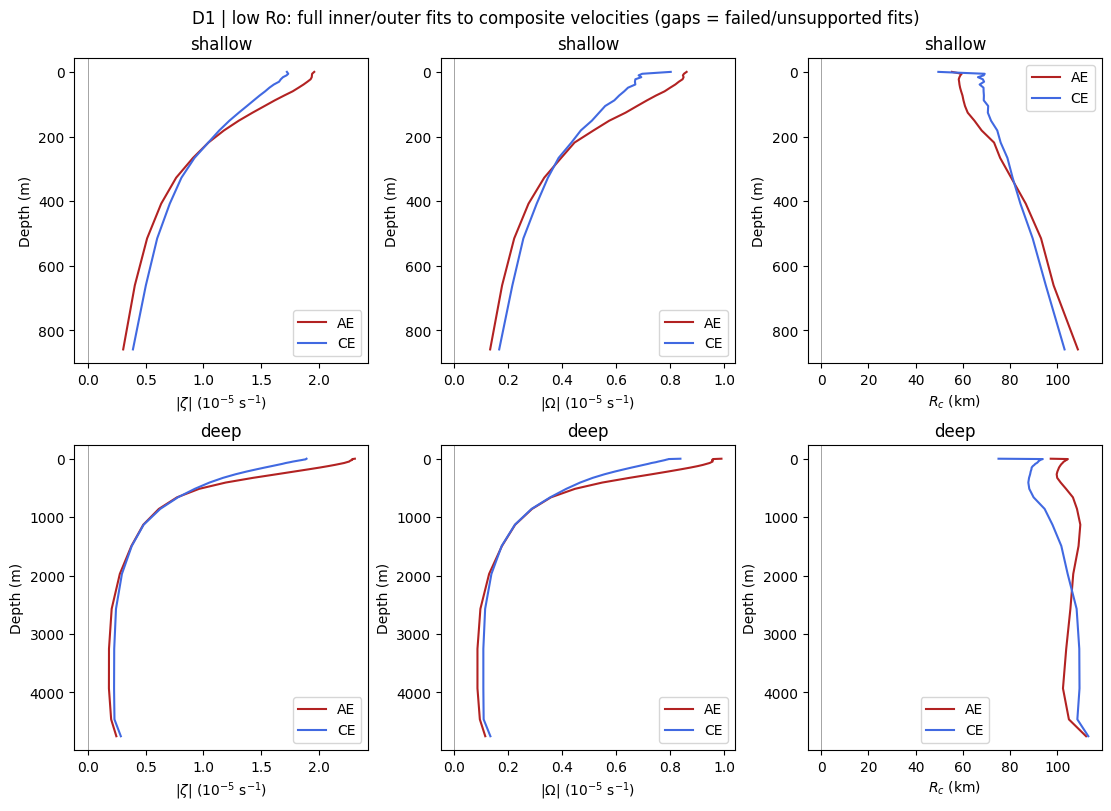

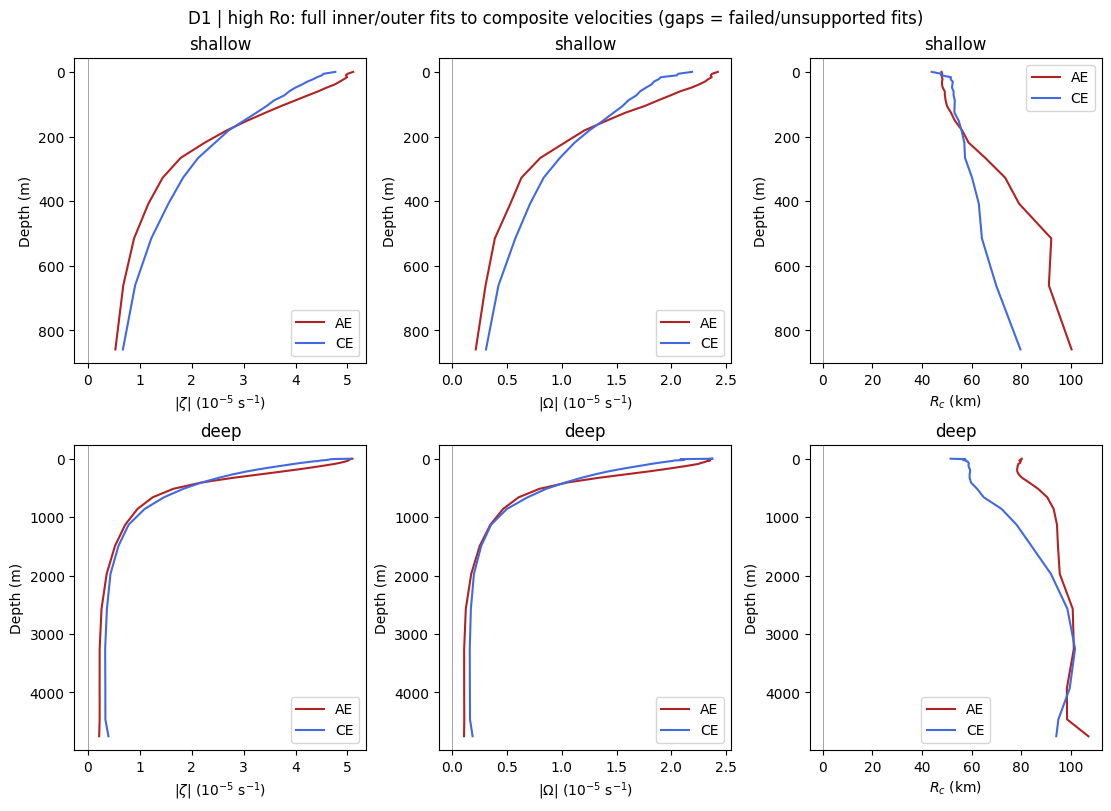

In [18]:
FIT_REGIONS=list(rct.REGIONS)
FIT_PLOT_REGIONS=[FOCUS_REGION]  # set to list(rct.REGIONS) to show all 12 panels of populations
comparison_sets=rct.comparison_sets(regional_results,FIT_REGIONS)
composite_esp_fits=pd.DataFrame();composite_fit_audit=pd.DataFrame()
if RUN_COMPOSITE_FITS:
    composite_esp_fits,composite_fit_audit=ccomp.fit_collections(comparison_sets,X,Y,esp,
        min_eddies=MIN_PLOT_EDDIES,transect_radius_km=30.,rho_min_km=30.,rho_max_km=200.,
        out_core_fac=1.75,max_jump_km=100.,min_cell_days=1)
    display(composite_fit_audit)
    if not composite_esp_fits.empty:
        display(composite_esp_fits)
        display(composite_esp_fits.loc[~composite_esp_fits.fit_ok,['population','cohort','Cyc','Depth','reason']])
        for region in FIT_PLOT_REGIONS:
            for ro in ['low','high']:
                label=f'{region} | {ro} Ro'
                if composite_esp_fits.population.eq(label).any():
                    ccomp.plot_fit_profiles(composite_esp_fits,label);plt.show()
else:print('Full composite ESP fits skipped')


## Horizontal and geographic vertical sections
Use the focus region/cohort/Rossby controls above. The horizontal maps use native model-grid axes and share an AE/CE speed scale. The two vertical cuts are geographic **zonal (meridional velocity)** and **meridional (zonal velocity)** through the surface centre. Sampling locations and velocities are rotated together; interpolation is horizontal only. Cuts do not follow a deeper centre that moves away from the surface reference.

The controls select visualisations only: all nonempty populations have already been reconstructed. Missing depths/groups remain labelled, not replaced with a neighbouring population or depth.


,target_m,Depth,status
0,500.0,515.416489,ok


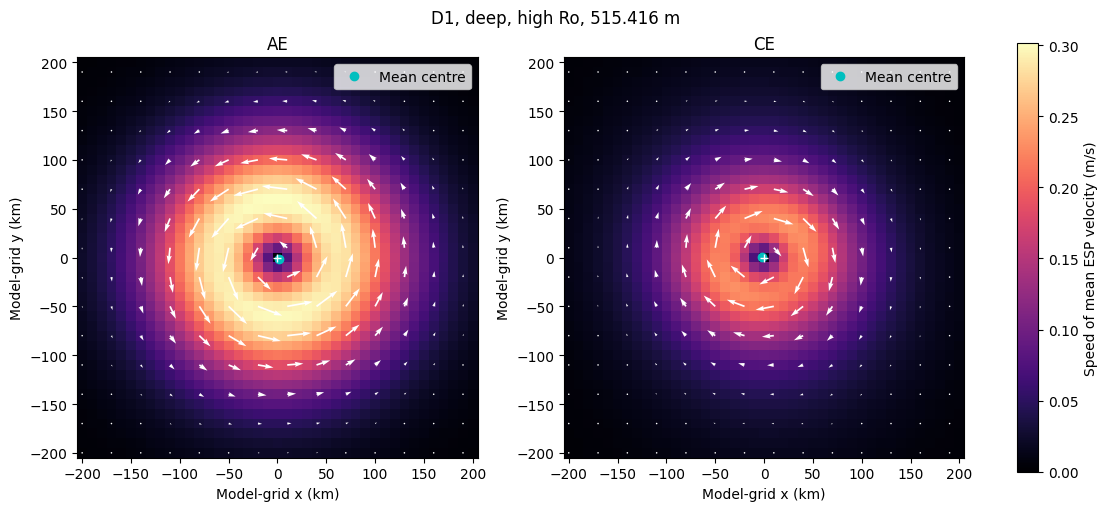

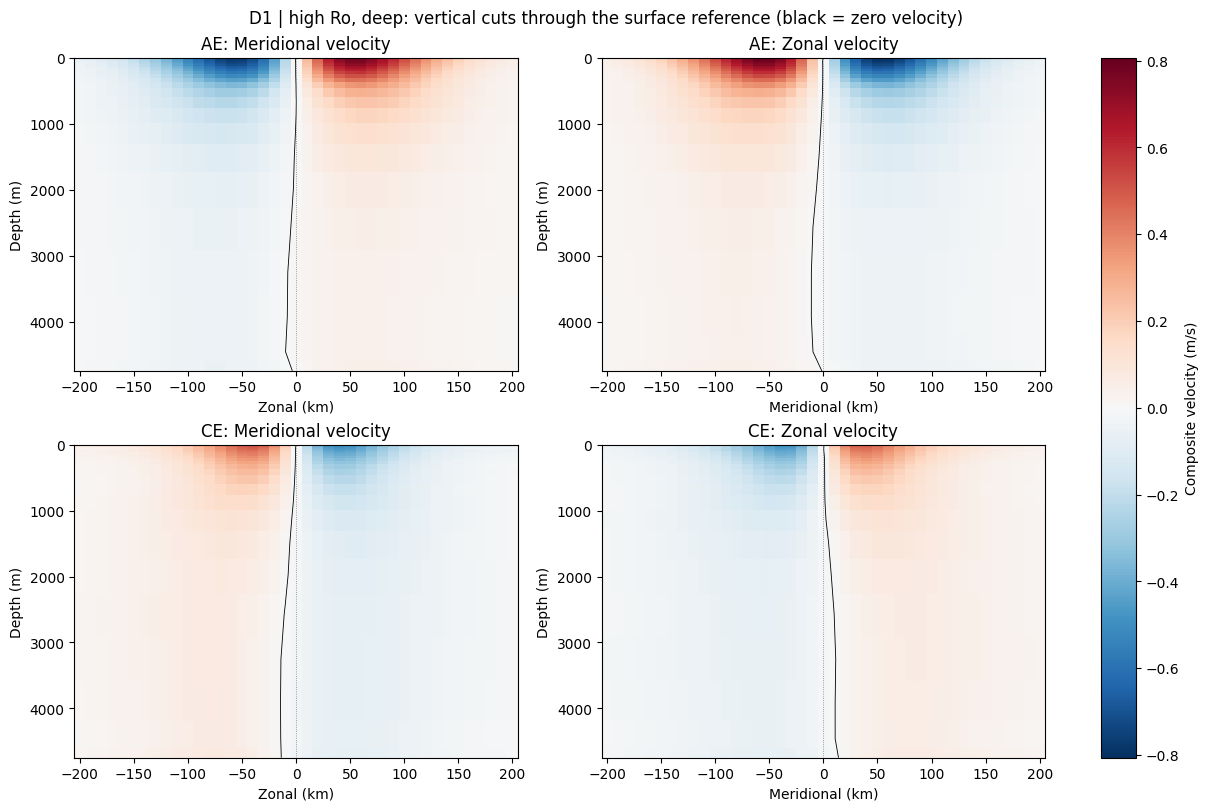

In [19]:
MAP_TARGET_DEPTH_M=500.
map_depth_map=rct.resolve_depths(centred_profiles.Depth.unique(),[MAP_TARGET_DEPTH_M],DEPTH_TOLERANCE_M)
display(map_depth_map)
map_depth=float(map_depth_map.Depth.iloc[0])
fig=rct.horizontal_maps(regional_results,X,Y,FOCUS_REGION,FOCUS_COHORT,FOCUS_RO_CLASS,map_depth)
if fig is not None:plt.show()
else:print('No horizontal velocity map for this exact depth/group; check support and reconstruction mode.')
section_results={(cohort,cyc):r for (region,cohort,ro,cyc),r in regional_results.items()
    if region==FOCUS_REGION and ro==FOCUS_RO_CLASS}
fig=ccomp.plot_sections(section_results,X,Y,f'{FOCUS_REGION} | {FOCUS_RO_CLASS} Ro',FOCUS_COHORT,
    rotation_rad=grid.angle,frame='geographic',min_eddies=MIN_PLOT_EDDIES)
if fig is not None:plt.show()
else:print('No reconstructed velocity sections for this group.')


## Optional output tables
The 60-slot inventory, input/reconstruction audits, depth support, physical and normalised statistics, matched checks, environmental context and full ESP fits remain available as named dataframes. `regional_results` retains member centres and velocity arrays. Exports below overwrite only the regional tables/settings in their own directory; no pickle cache or raw velocity volume is written.


In [14]:
SAVE_TABLES=False
if SAVE_TABLES:
    out=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/regional_composite_tilt')
    out.mkdir(parents=True,exist_ok=True)
    for name in ['population_inventory','contributor_inventory','reconstruction_audit','centre_stats',
                 'normalised_centre_stats','tilt_summary','depth_map','matched_audit','matched_centre_stats',
                 'matched_normalised_stats','population_context','composite_esp_fits','composite_fit_audit']:
        globals()[name].to_csv(out/f'{name}.csv',index=False)
    (out/'settings.json').write_text(json.dumps(dict(regions=list(rct.REGIONS),split_depth_m=SPLIT_DEPTH_M,
        rossby_split=ROSSBY_SPLIT,rossby='absolute surface w/f; high includes equality',weighting='equal day',
        dominance_factor=DOMINANCE_FACTOR,shelf_lon=SHELF_LON,grid_angle_rad=float(grid.angle),
        bootstrap_draws=BOOTSTRAPS,seed=SEED,minimum_plot_eddies=MIN_PLOT_EDDIES,sparse_eddies=SPARSE_EDDIES,
        summary_target_m=SUMMARY_TARGET_DEPTH_M,depth_tolerance_m=DEPTH_TOLERANCE_M,
        match_shallow_targets_m=MATCH_SHALLOW_TARGETS_M,match_deep_targets_m=MATCH_DEEP_TARGETS_M,
        width_km=WIDTH_KM,resolution_km=RES_KM,velocity=RUN_VELOCITY_COMPOSITES,
        fit_regions=FIT_REGIONS,fit_enabled=RUN_COMPOSITE_FITS,n2_cache=str(N2_CACHE),
        n2_min_valid_fraction=MIN_N2_CORE_VALID_FRACTION),indent=2))
    print(out)
